In [13]:
# import
import h5py
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
from scipy.stats import sem, pearsonr
import pandas as pd

from functions import neuron_reliability, reliability_filtering_tb, reliability_filtering

Figure 3 A

In [3]:
# load neural data for Pico
p_file_s5 = h5py.File('data/230801.pico.rsvp.gratingsAdap_s5.experiment_psth_raw.h5','r')
p_file_s3 = h5py.File('data/230801.pico.rsvp.gratingsAdap_s3.experiment_psth_raw.h5','r')
p_file_s4 = h5py.File('data/230801.pico.rsvp.gratingsAdap_s4.experiment_psth_raw.h5','r')

p_rates_s5 = p_file_s5['/psth'][:]
p_rates_s3 = p_file_s3['/psth'][:]
p_rates_s4 = p_file_s4['/psth'][:]

In [4]:
# determine which ones are reliable neurons
s5_neural_pico = np.transpose(np.nanmean(p_rates_s5[:,:,7:17,:],axis=2), (0,2,1))
p_rel = neuron_reliability(s5_neural_pico)[0]

/tmp/ipykernel_473525/241027996.py:2: RuntimeWarning: Mean of empty slice
  s5_neural_pico = np.transpose(np.nanmean(p_rates_s5[:,:,7:17,:],axis=2), (0,2,1))


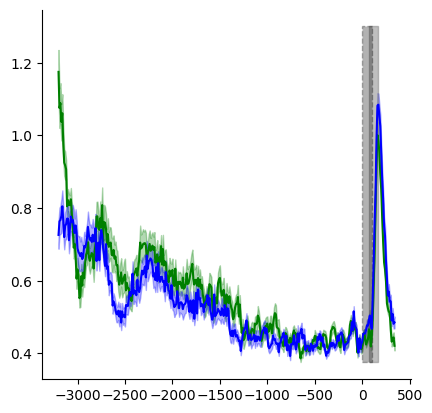

In [12]:
# plot the change in neural response over time 
plt_s3 = reliability_filtering_tb(p_rates_s3,p_rel,metric=0.2)
plt_s4 = reliability_filtering_tb(p_rates_s4,p_rel,metric=0.2)

plt_s3 = np.nanmean(np.nanmean(plt_s3[:,:,10:,:],axis=3),axis=1)
plt_s4 = np.nanmean(np.nanmean(plt_s4[:,:,10:,:],axis=3),axis=1)

# plot the average across images and with error of sem across images
t = range(-3200,350,10) # the full range of the data 

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.plot(t,np.nanmean(plt_s3[:,:355],axis=0),color='green')
plt.fill_between(t,y1=np.nanmean(plt_s3[:,:355],axis=0)-sem(plt_s3[:,:355],axis=0),y2=np.nanmean(plt_s3[:,:355],axis=0)+sem(plt_s3[:,:355],axis=0),color='green',alpha=0.3)

plt.plot(t,np.nanmean(plt_s4[:,:355],axis=0),color='blue')
plt.fill_between(t,y1=np.nanmean(plt_s4[:,:355],axis=0)-sem(plt_s4[:,:355],axis=0),y2=np.nanmean(plt_s4[:,:355],axis=0)+sem(plt_s4[:,:355],axis=0),color='blue',alpha=0.3)

toi = Rectangle((70,0.375),width=100,height=1.3-0.375,color='grey',alpha=0.5) # the time we are interested in
plt.gca().add_patch(toi)

im_pres = Rectangle((0,0.375),width=100,height=1.3-0.375,color='black',linestyle='--',alpha=0.3) # image presentation
plt.gca().add_patch(im_pres)

x0,x1 = plt.gca().get_xlim()
y0,y1 = plt.gca().get_ylim()

plt.gca().set_aspect(abs(x1-x0)/abs(y1-y0))

# save the plot
# plt.savefig('/home/eyakub/scratch/neural_timeseries.eps', format='eps', bbox_inches='tight')

Figure 3 B

In [2]:
# load the neural data
p_file_s5 = h5py.File('data/230801.pico.rsvp.gratingsAdap_s5.experiment_psth_raw.h5','r')
k_file_s5 = h5py.File('data/kenny_season5.mat','r')

p_file_s3 = h5py.File('data/230801.pico.rsvp.gratingsAdap_s3.experiment_psth_raw.h5','r')
k_file_s3 = h5py.File('data/kenny_season3.mat','r')

p_file_s4 = h5py.File('data/230801.pico.rsvp.gratingsAdap_s4.experiment_psth_raw.h5','r')
k_file_s4 = h5py.File('data/kenny_season4.mat','r')

p_rates_s5 = p_file_s5['/psth'][:]
k_rates_s5 = k_file_s5['/rates'][:]

p_rates_s3 = p_file_s3['/psth'][:]
k_rates_s3 = k_file_s3['/kenny_s3'][:]

p_rates_s4 = p_file_s4['/psth'][:]
k_rates_s4 = k_file_s4['/kenny_s4'][:]

In [3]:
# getting 70-170 ms for S5
s5_neural_pico = np.transpose(np.nanmean(p_rates_s5[:,:,7:17,:],axis=2), (0,2,1))
s5_neural_kenny = k_rates_s5

# concatenate Pico and Kenny's data
s5_neural = np.concatenate((s5_neural_pico,s5_neural_kenny),axis=1)

# get the neuron reliabilities for 70-170 ms
rel, std_rel = neuron_reliability(s5_neural)

# filter neurons to include only those with r > 0.2
s5_neural = reliability_filtering(s5_neural,rel,metric=0.2)

# get the standard deviation for each neuron and each image across trials 
s5_neural_mean = np.nanmean(s5_neural,axis=2)
s5_neural_std = np.nanstd(s5_neural,axis=2)

/tmp/ipykernel_482551/2802065718.py:2: RuntimeWarning: Mean of empty slice
  s5_neural_pico = np.transpose(np.nanmean(p_rates_s5[:,:,7:17,:],axis=2), (0,2,1))


In [4]:
# getting 70-170 ms for S3 and S4
s3_neural_pico = np.transpose(np.nanmean(p_rates_s3[:,:,337:347,:],axis=2), (0,2,1)) 
s4_neural_pico = np.transpose(np.nanmean(p_rates_s4[:,:,337:347,:],axis=2), (0,2,1))
s3_neural_kenny = k_rates_s3
s4_neural_kenny = k_rates_s4

# concatenate the data from Pico and Kenny
s3_neural = np.concatenate((s3_neural_pico,s3_neural_kenny), axis=1)
s4_neural = np.concatenate((s4_neural_pico,s4_neural_kenny), axis=1)

# filtering such that only neurons with r > 0.2 are left for S3 and S4
s3_neural = reliability_filtering(s3_neural,rel,metric=0.2)
s4_neural = reliability_filtering(s4_neural,rel,metric=0.2)

# get the standard deviation across trials
s3_neural_mean = np.nanmean(s3_neural,axis=2)
s4_neural_mean = np.nanmean(s4_neural,axis=2)
s3_neural_std = np.nanstd(s3_neural,axis=2)
s4_neural_std = np.nanstd(s4_neural,axis=2)

In [5]:
# getting the reliability of the included neurons for their season, no spearman-brown correction
s5_rels = neuron_reliability(s5_neural,sb_correct=False)[0]
s3_rels = neuron_reliability(s3_neural,sb_correct=False)[0]
s4_rels = neuron_reliability(s4_neural,sb_correct=False)[0]

In [9]:
# define a function to do subsampled correlation 
def sub_samp_corr(data1,data2,data1_rel,data2_rel,runs=20):
    '''
    data1 and data2 = [n_img,n_trials]
    '''
    emp = np.empty(20)
    emp_corr = np.empty(20)
    for x in range(runs):
        rng1 = np.random.default_rng(seed=x)
        rng2 = np.random.default_rng(seed=2*(x+1))
        random_indices_1 = rng1.choice(data1.shape[1], size=int(data1.shape[1]/2), replace=False)
        random_indices_2 = rng2.choice(data2.shape[1], size=int(data2.shape[1]/2), replace=False)
        data1_sub = np.nanmean(data1[:,random_indices_1],axis=1)
        data2_sub = np.nanmean(data2[:,random_indices_2],axis=1)
        R = pearsonr(data1_sub,data2_sub)[0]
        emp[x]= R
        emp_corr[x] = R/((data1_rel*data2_rel)**0.5)
    return [np.nanmean(emp),np.nanmean(emp_corr),np.nanstd(emp_corr)]

In [10]:
# get the correlations between S5 and S3 and S5 and S4 for all reliable neurons
s3_s5 = []
s4_s5 = []

s3_s5_plain = []
s3_s5_std_plain = []
s4_s5_plain = []
s4_s5_std_plain = []

s3_s5_uncorr = []
s4_s5_uncorr = []

for i in range(s5_neural.shape[1]):
    s5t = np.squeeze(s5_neural[:,i,:])
    s3t = np.squeeze(s3_neural[:,i,:])
    s4t = np.squeeze(s4_neural[:,i,:])
    
    s53_r, s53_r_corr, s53_r_std = sub_samp_corr(s5t,s3t,s5_rels[i],s3_rels[i])
    s3_s5.append({'idx':i,'r':s53_r_corr,'std':s53_r_std})
    s3_s5_uncorr.append({'idx':i,'r':s53_r})
    
    s3_s5_plain.append(s53_r_corr)
    s3_s5_std_plain.append(s53_r_std)
    
    s54_r, s54_r_corr, s54_r_std = sub_samp_corr(s5t,s4t,s5_rels[i],s4_rels[i])
    s4_s5.append({'idx':i,'r':s54_r_corr,'std':s54_r_std})
    s4_s5_uncorr.append({'idx':i,'r':s54_r})
    
    s4_s5_plain.append(s54_r_corr)
    s4_s5_std_plain.append(s54_r_std)

/tmp/ipykernel_482551/1822782760.py:17: RuntimeWarning: invalid value encountered in scalar power
  emp_corr[x] = R/((data1_rel*data2_rel)**0.5)
/tmp/ipykernel_482551/1822782760.py:18: RuntimeWarning: Mean of empty slice
  return [np.nanmean(emp),np.nanmean(emp_corr),np.nanstd(emp_corr)]
/home/eyakub/scratch/.obj_pos_venv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [11]:
# sort the correlations 

# helper function to sort by the entry in 'r'
def helper(e):
  return e['r']
    
s3_s5_sorted = sorted(s3_s5,key=helper)

# sort R(S4,S5) based on the indices in s3_s5_sorted

# get the order of 'idx' values from the sorted s3_s5
idx_order = [d['idx'] for d in s3_s5_sorted]

# make a lookup for s4_s5 by idx for fast access
s4_s5_lookup = {d['idx']: d for d in s4_s5}

# sort s4_s5 according to the order of idx in s3_s5_sorted
s4_s5_sorted = [s4_s5_lookup[i] for i in idx_order if i in s4_s5_lookup]

# sort the uncorrected versions 
s3_s5_uncorr_sorted = sorted(s3_s5_uncorr,key=helper)
s4_s5_uncorr_sorted = sorted(s4_s5_uncorr,key=helper)

In [14]:
# process the correlations so that they are easier to plot, exclude anything that is nan
s3_s5_df = pd.DataFrame(s3_s5_sorted) 
s4_s5_df = pd.DataFrame(s4_s5_sorted)

s3_s5_r = s3_s5_df['r'].to_numpy()
s35_mask = np.isnan(s3_s5_r)
s3_s5_r = s3_s5_r[~s35_mask]
s3_s5_std = s3_s5_df['std'].to_numpy()[~s35_mask]

s4_s5_r = s4_s5_df['r'].to_numpy()
s45_mask = np.isnan(s4_s5_r)
s4_s5_r = s4_s5_r[~s45_mask]
s4_s5_std = s4_s5_df['std'].to_numpy()[~s45_mask]

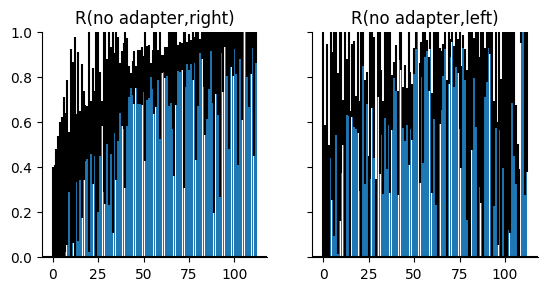

In [15]:
# plot the correlations for all the neurons we have for both R(no adapter,right) and R(no adapter,left)
fig,axs = plt.subplots(1,2,sharey=True)

axs[0].bar(range(len(s3_s5_r)),s3_s5_r,yerr=s3_s5_std)
axs[0].set(title='R(no adapter,right)')

axs[1].bar(range(len(s4_s5_r)),s4_s5_r,yerr=s4_s5_std)
axs[1].set(title='R(no adapter,left)')


for n in range(2):
    axs[n].axhline(y=0, color='k')
    axs[n].spines['top'].set_visible(False)
    axs[n].spines['right'].set_visible(False)
    axs[n].set_ylim(0,1)
    x0, x1 = axs[n].get_xlim()
    y0, y1 = axs[n].get_ylim()
    axs[n].set_aspect(abs(x1 - x0) / abs(y1 - y0), adjustable='box')

# plt.savefig('/home/eyakub/scratch/s345_corrs_bar.eps', format='eps', bbox_inches='tight')